# Radius ROC-AUC Panels for Three Experiments

This notebook builds one figure per experiment. Each figure has five panels, one for each session, and each panel plots ROC-AUC against radius (1, 2, 3, 4, 5 km).

Where the results come from:
- Experiment 2 reads `test_fold_evaluation.json` from each fold folder under `radius_dual_norwegain_only-unfreeze-backbone`.
- Experiment 3 reads `fold_summary.json` and uses `training_result.test_metrics.auc` from `aerosonic_to_norwegian_ex3`.
- Experiment 4 reads `fold_summary.json` and uses `training_result.test_metrics.auc` from `norwegian-aerosonic-and-augmented`.

The notebook also prints a source table so you can verify the exact file used for every radius/session point.

In [2]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")

In [12]:
EXPERIMENTS = {
    "Experiment 2: radius_dual_norwegain_onlu-unfreeze-backbone": {
        "fold_leaf_dir": "norwegian_dual_radius_posneg",
        "radius_dirs": {
            1: Path(r"E:\\history\\sound-event-detection-aircrafts\\final_runs\\radius_dual_norwegain_only-unfreeze-backbone\\20260525-110433Z\\radius_dual_pos_1km_neg_10km_wnone"),
            2: Path(r"E:\\history\\sound-event-detection-aircrafts\\final_runs\\radius_dual_norwegain_only-unfreeze-backbone\\20260525-161827Z\\radius_dual_pos_2km_neg_10km_wnone"),
            3: Path(r"E:\\history\\sound-event-detection-aircrafts\\final_runs\\radius_dual_norwegain_only-unfreeze-backbone\\20260522-172720Z\\radius_dual_pos_3km_neg_10km_wnone"),
            4: Path(r"E:\\history\\sound-event-detection-aircrafts\\final_runs\\radius_dual_norwegain_only-unfreeze-backbone\\20260522-220158Z\\radius_dual_pos_4km_neg_10km_wnone"),
            5: Path(r"E:\\history\\sound-event-detection-aircrafts\\final_runs\\radius_dual_norwegain_only-unfreeze-backbone\\20260523-012120Z\\radius_dual_pos_5km_neg_10km_wnone"),
        },
    },
    "Experiment 3: aerosonic_to_norwegian_ex3": {
        "fold_leaf_dir": "aero_only_to_norwegian",
        "radius_dirs": {
            1: Path(r"E:\\history\\sound-event-detection-aircrafts\\final_runs\\aerosonic_to_norwegian_ex3\\20260525-090214Z\\radius_dual_pos_1km_neg_10km_wnone"),
            2: Path(r"E:\\history\\sound-event-detection-aircrafts\\final_runs\\aerosonic_to_norwegian_ex3\\20260526-171718Z\\radius_dual_pos_2km_neg_10km_wnone"),
            3: Path(r"E:\\history\\sound-event-detection-aircrafts\\final_runs\\aerosonic_to_norwegian_ex3\\20260525-195411Z\\radius_dual_pos_3km_neg_10km_wnone"),
            4: Path(r"E:\\history\\sound-event-detection-aircrafts\\final_runs\\aerosonic_to_norwegian_ex3\\20260525-233358Z\\radius_dual_pos_4km_neg_10km_wnone"),
            5: Path(r"E:\\history\\sound-event-detection-aircrafts\\final_runs\\aerosonic_to_norwegian_ex3\\20260526-032835Z\\radius_dual_pos_5km_neg_10km_wnone"),
        },
    },
    "Experiment 4: norwegain-aerosonic-and-augmetned": {
        "fold_leaf_dir": "aero_plus_norwegian_with_aug",
        "radius_dirs": {
            1: Path(r"E:\\history\\sound-event-detection-aircrafts\\final_runs\\norwegian-aerosonic-and-augmented\\20260526-070622Z\\radius_dual_pos_1km_neg_10km_wnone"),
            2: Path(r"E:\\history\\sound-event-detection-aircrafts\\final_runs\\norwegian-aerosonic-and-augmented\\20260526-202559Z\\radius_dual_pos_2km_neg_10km_wnone"),
            3: Path(r"E:\\history\\sound-event-detection-aircrafts\\final_runs\\norwegian-aerosonic-and-augmented\\20260522-004437Z\\radius_dual_pos_3km_neg_10km_wnone"),
            4: Path(r"E:\\history\\sound-event-detection-aircrafts\\final_runs\\norwegian-aerosonic-and-augmented\\20260521-172853Z\\radius_dual_pos_4km_neg_10km_wnone"),
            5: Path(r"E:\\history\\sound-event-detection-aircrafts\\final_runs\\norwegian-aerosonic-and-augmented\\20260521-160800Z\\radius_dual_pos_5km_neg_10km_wnone"),
        },
    },
}

FOLD_IDS = [0, 1, 2, 3, 4]
RADIUS_VALUES = [1, 2, 3, 4, 5]
METRIC_CANDIDATES = [
    "test_fold_evaluation.json",
    "fold_summary.json",
    "single_fold_result.json",
    Path("training") / "result.json",
]

In [13]:
def find_metric_file(fold_dir: Path) -> Path | None:
    for candidate in METRIC_CANDIDATES:
        candidate_path = fold_dir / candidate
        if candidate_path.exists():
            return candidate_path
    return None


def extract_auc(json_path: Path) -> float:
    payload = json.loads(json_path.read_text(encoding="utf-8"))

    candidate_paths = [
        ("metrics", "auc"),
        ("training_result", "test_metrics", "auc"),
        ("result", "metrics", "auc"),
        ("test_metrics", "auc"),
    ]

    for keys in candidate_paths:
        node = payload
        try:
            for key in keys:
                node = node[key]
            return float(node)
        except (KeyError, TypeError, ValueError):
            continue

    return np.nan


fold_to_session = {
    0: 3,
    1: 2,
    2: 4, 
    3: 1,
    4: 5
}


def load_experiment(experiment_name: str, spec: dict) -> pd.DataFrame:
    rows = []

    for radius_km in RADIUS_VALUES:
        radius_dir = spec["radius_dirs"][radius_km]
        fold_root = radius_dir / spec["fold_leaf_dir"]

        for fold_id in FOLD_IDS:
            fold_dir = fold_root / f"fold_{fold_id}_test_{fold_id}"
            session_id = fold_to_session[fold_id]  # Map fold_id to session_id

            # metric file (various possible files)
            metric_file = find_metric_file(fold_dir)
            auc = extract_auc(metric_file) if metric_file is not None else np.nan

            # extract fold status from fold_summary.json if present
            status = None
            summary_path = fold_dir / "fold_summary.json"
            if summary_path.exists():
                try:
                    summary = json.loads(summary_path.read_text(encoding="utf-8"))
                    status = summary.get("status") or summary.get("result", {}).get("status")
                except Exception:
                    status = None

            rows.append({
                "experiment": experiment_name,
                "session": session_id,
                "radius_km": radius_km,
                "roc_auc": auc,
                "status": status,
                "metric_file": str(metric_file) if metric_file is not None else None,
                "fold_dir": str(fold_dir),
            })

    return pd.DataFrame(rows)


all_results = pd.concat(
    [load_experiment(name, spec) for name, spec in EXPERIMENTS.items()],
    ignore_index=True,
)

display(all_results.sort_values(["experiment", "session", "radius_km"]))

,experiment,session,radius_km,roc_auc,status,metric_file,fold_dir
3,Experiment 2: radius_dual_norwegain_onlu-unfre...,1,1,0.123611,completed,E:\history\sound-event-detection-aircrafts\fin...,E:\history\sound-event-detection-aircrafts\fin...
8,Experiment 2: radius_dual_norwegain_onlu-unfre...,1,2,0.831340,completed,E:\history\sound-event-detection-aircrafts\fin...,E:\history\sound-event-detection-aircrafts\fin...
13,Experiment 2: radius_dual_norwegain_onlu-unfre...,1,3,0.593755,completed,E:\history\sound-event-detection-aircrafts\fin...,E:\history\sound-event-detection-aircrafts\fin...
18,Experiment 2: radius_dual_norwegain_onlu-unfre...,1,4,0.671519,completed,E:\history\sound-event-detection-aircrafts\fin...,E:\history\sound-event-detection-aircrafts\fin...
23,Experiment 2: radius_dual_norwegain_onlu-unfre...,1,5,0.565997,completed,E:\history\sound-event-detection-aircrafts\fin...,E:\history\sound-event-detection-aircrafts\fin...
...,...,...,...,...,...,...,...
54,Experiment 4: norwegain-aerosonic-and-augmetned,5,1,0.227954,completed,E:\history\sound-event-detection-aircrafts\fin...,E:\history\sound-event-detection-aircrafts\fin...
59,Experiment 4: norwegain-aerosonic-and-augmetned,5,2,0.915202,completed,E:\history\sound-event-detection-aircrafts\fin...,E:\history\sound-event-detection-aircrafts\fin...
64,Experiment 4: norwegain-aerosonic-and-augmetned,5,3,0.504792,completed,E:\history\sound-event-detection-aircrafts\fin...,E:\history\sound-event-detection-aircrafts\fin...
69,Experiment 4: norwegain-aerosonic-and-augmetned,5,4,NaN,failed,E:\history\sound-event-detection-aircrafts\fin...,E:\history\sound-event-detection-aircrafts\fin...


In [14]:
# Display only rows where ROC-AUC is NaN to inspect missing results
nan_rows = all_results[all_results['roc_auc'].isna()].copy()
if len(nan_rows) == 0:
    print('No NaN ROC-AUC rows found')
else:
    display(nan_rows.sort_values(['experiment', 'session', 'radius_km']))
    print(f"Total NaN rows: {len(nan_rows)}")

# Also show unique metric files for NaN rows to inspect file locations
if len(nan_rows):
    print('\nUnique metric files for NaN rows:')
    print('\n'.join(sorted(filter(None, nan_rows['metric_file'].unique().tolist()))))

,experiment,session,radius_km,roc_auc,status,metric_file,fold_dir
1,Experiment 2: radius_dual_norwegain_onlu-unfre...,2,1,NaN,skipped,E:\history\sound-event-detection-aircrafts\fin...,E:\history\sound-event-detection-aircrafts\fin...
0,Experiment 2: radius_dual_norwegain_onlu-unfre...,3,1,NaN,skipped,E:\history\sound-event-detection-aircrafts\fin...,E:\history\sound-event-detection-aircrafts\fin...
5,Experiment 2: radius_dual_norwegain_onlu-unfre...,3,2,NaN,skipped,E:\history\sound-event-detection-aircrafts\fin...,E:\history\sound-event-detection-aircrafts\fin...
26,Experiment 3: aerosonic_to_norwegian_ex3,2,1,NaN,skipped,E:\history\sound-event-detection-aircrafts\fin...,E:\history\sound-event-detection-aircrafts\fin...
25,Experiment 3: aerosonic_to_norwegian_ex3,3,1,NaN,skipped,E:\history\sound-event-detection-aircrafts\fin...,E:\history\sound-event-detection-aircrafts\fin...
30,Experiment 3: aerosonic_to_norwegian_ex3,3,2,NaN,skipped,E:\history\sound-event-detection-aircrafts\fin...,E:\history\sound-event-detection-aircrafts\fin...
63,Experiment 4: norwegain-aerosonic-and-augmetned,1,3,NaN,failed,E:\history\sound-event-detection-aircrafts\fin...,E:\history\sound-event-detection-aircrafts\fin...
68,Experiment 4: norwegain-aerosonic-and-augmetned,1,4,NaN,failed,E:\history\sound-event-detection-aircrafts\fin...,E:\history\sound-event-detection-aircrafts\fin...
73,Experiment 4: norwegain-aerosonic-and-augmetned,1,5,NaN,failed,E:\history\sound-event-detection-aircrafts\fin...,E:\history\sound-event-detection-aircrafts\fin...
51,Experiment 4: norwegain-aerosonic-and-augmetned,2,1,NaN,skipped,E:\history\sound-event-detection-aircrafts\fin...,E:\history\sound-event-detection-aircrafts\fin...


Total NaN rows: 20

Unique metric files for NaN rows:
E:\history\sound-event-detection-aircrafts\final_runs\aerosonic_to_norwegian_ex3\20260525-090214Z\radius_dual_pos_1km_neg_10km_wnone\aero_only_to_norwegian\fold_0_test_0\fold_summary.json
E:\history\sound-event-detection-aircrafts\final_runs\aerosonic_to_norwegian_ex3\20260525-090214Z\radius_dual_pos_1km_neg_10km_wnone\aero_only_to_norwegian\fold_1_test_1\fold_summary.json
E:\history\sound-event-detection-aircrafts\final_runs\aerosonic_to_norwegian_ex3\20260526-171718Z\radius_dual_pos_2km_neg_10km_wnone\aero_only_to_norwegian\fold_0_test_0\fold_summary.json
E:\history\sound-event-detection-aircrafts\final_runs\norwegian-aerosonic-and-augmented\20260521-160800Z\radius_dual_pos_5km_neg_10km_wnone\aero_plus_norwegian_with_aug\fold_0_test_0\fold_summary.json
E:\history\sound-event-detection-aircrafts\final_runs\norwegian-aerosonic-and-augmented\20260521-160800Z\radius_dual_pos_5km_neg_10km_wnone\aero_plus_norwegian_with_aug\fold_1_test_

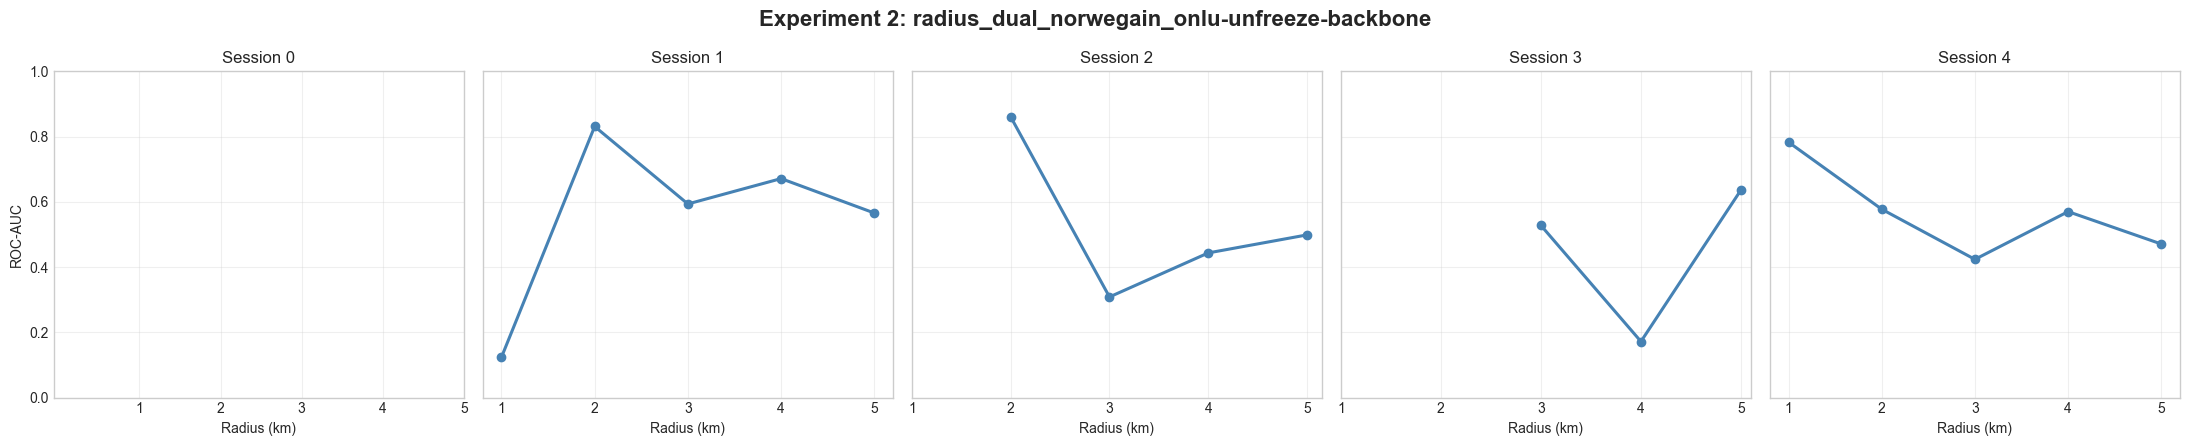

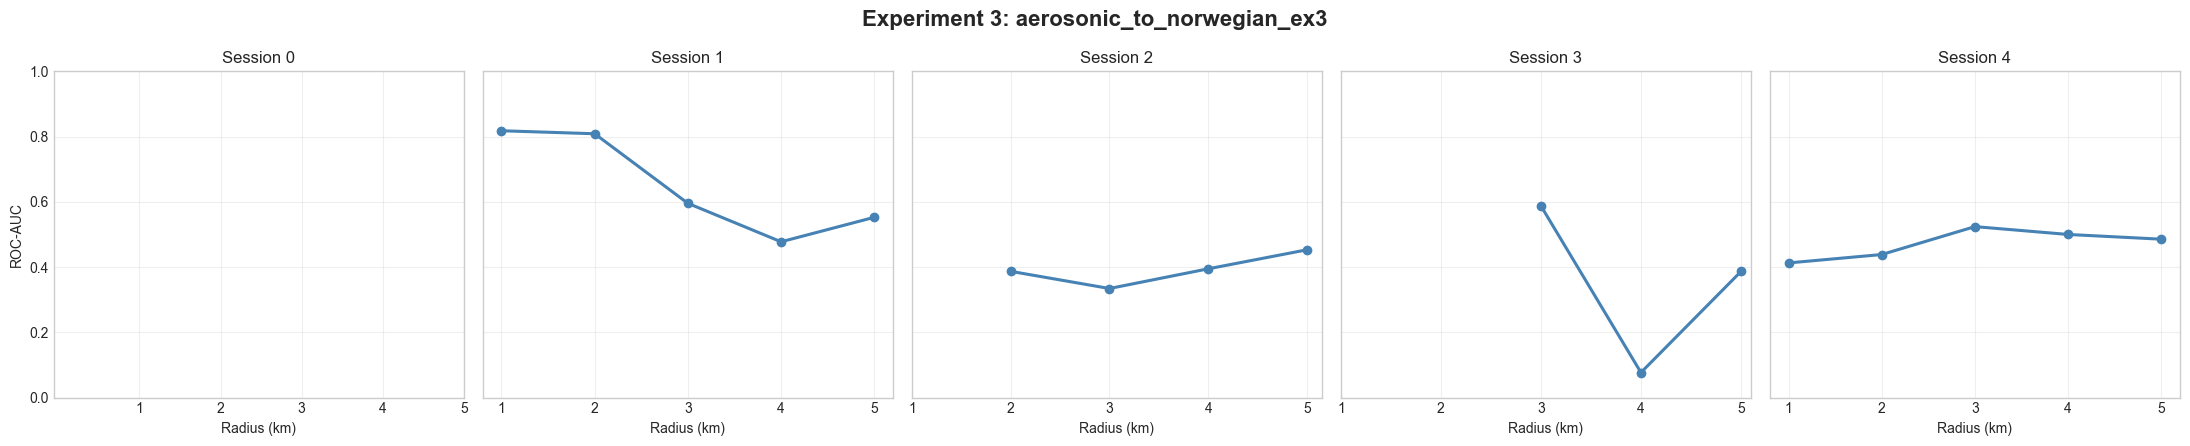

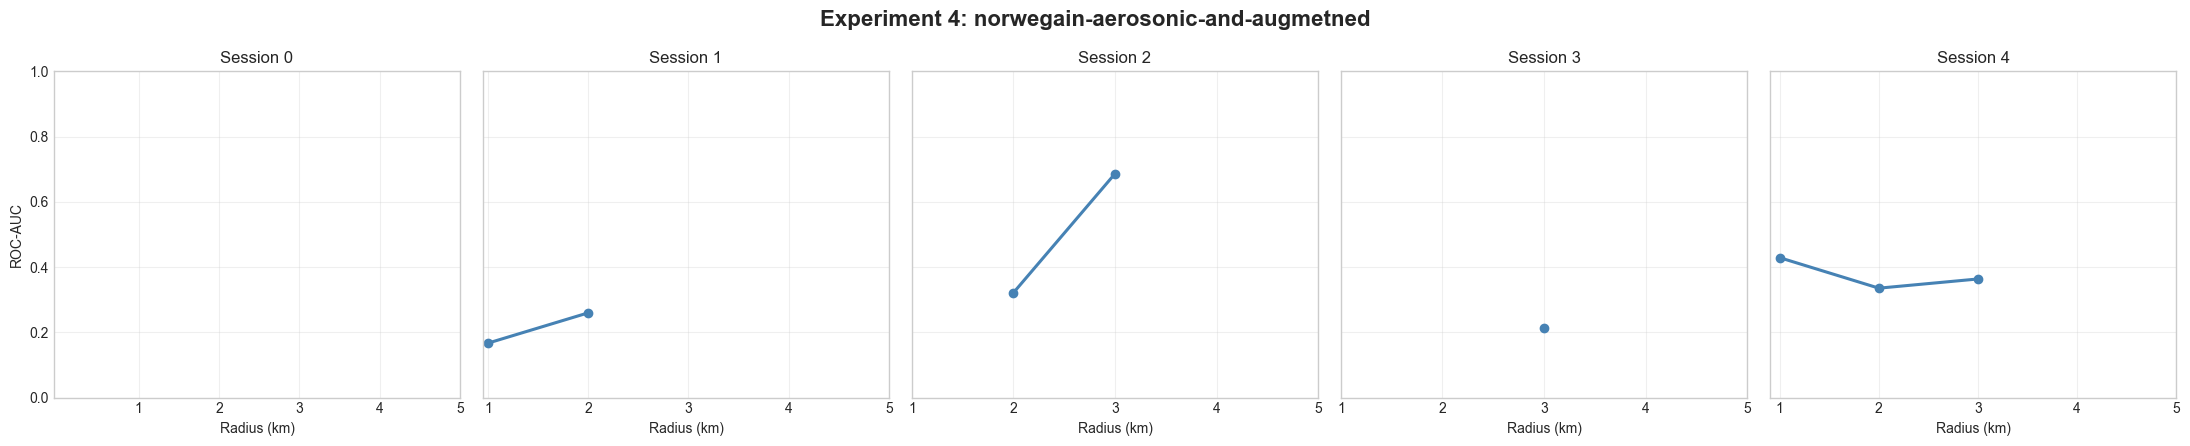

In [15]:
def plot_experiment_results(experiment_name: str, data: pd.DataFrame) -> None:
    fig, axes = plt.subplots(1, 5, figsize=(22, 4.5), sharey=True)
    fig.suptitle(experiment_name, fontsize=16, fontweight="bold")

    for axis, session_id in zip(axes, FOLD_IDS):
        session_data = data[data["session"] == session_id].sort_values("radius_km")
        axis.plot(session_data["radius_km"], session_data["roc_auc"], marker="o", linewidth=2.2, color="steelblue")
        axis.set_title(f"Session {session_id}")
        axis.set_xticks(RADIUS_VALUES)
        axis.set_xlabel("Radius (km)")
        axis.grid(alpha=0.3)
        axis.set_ylim(0.0, 1.0)

    axes[0].set_ylabel("ROC-AUC")
    fig.tight_layout()
    plt.show()


for experiment_name in EXPERIMENTS:
    experiment_data = all_results[all_results["experiment"] == experiment_name]
    plot_experiment_results(experiment_name, experiment_data)